# **Project: Credit Card Fraud Detection**


## **Problem Satement:**
Credit card fraud detection is challenging due to the highly imbalanced nature of transaction data. The goal of this project is to develop a machine learning model that can accurately identify fraudulent transactions while minimizing missed fraud cases.

#### **IMPORTING LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### **LOAD DATASET**

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/creditcard.csv', engine='python', on_bad_lines='skip')

## **DATA EXPLORATION**

#### **.head()**
to print the first five rows

In [ ]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


#### **.tail()**
to print the last five rows

In [ ]:
data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


#### **.shape**
to check the shape of given dataset

In [ ]:
data.shape

(284807, 31)

In [ ]:
print("Number of Rows",data.shape[0])
print("Number of Columns",data.shape[1])

Number of Rows 284807
Number of Columns 31


#### **.info()**
to check the information of given dataset

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

#### **.isnull().sum()**
to find the sum of null values in columns

In [ ]:
data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
data.isnull().sum().sum()

np.int64(0)

#### **.duplicated().sum()**
to find the sum of duplicates values in dataset

In [ ]:
data.duplicated().sum()

np.int64(1081)

In [ ]:
data.drop_duplicates(inplace=True)

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data = data.drop(['Time'],axis=1)

In [ ]:
data.shape

(283726, 30)

## **EDA**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

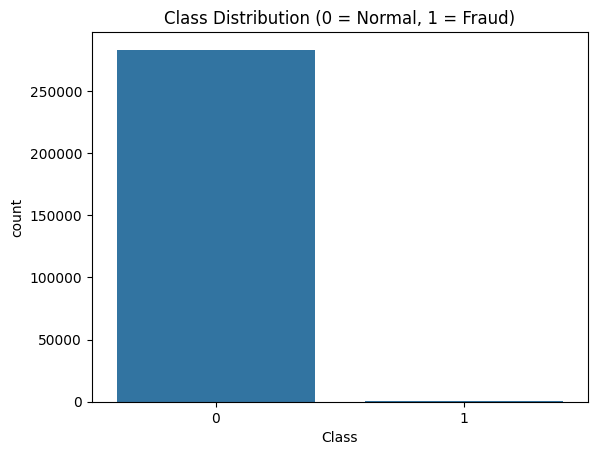

In [ ]:
sns.countplot(x='Class', data=data)
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.show()

##### ***the plot shows the severely imbalanced classes with far more normal(0) transaction than fraud(1).***

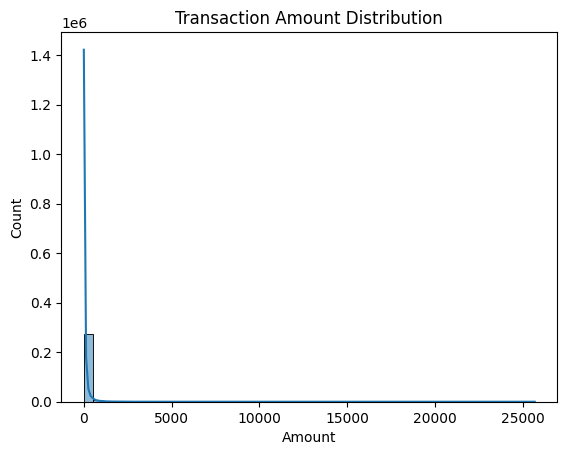

In [ ]:
sns.histplot(data['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

##### ***the plot shows the highly right-skewed distribution with most transactions at low amounts and a few extreme high-value outliers.***

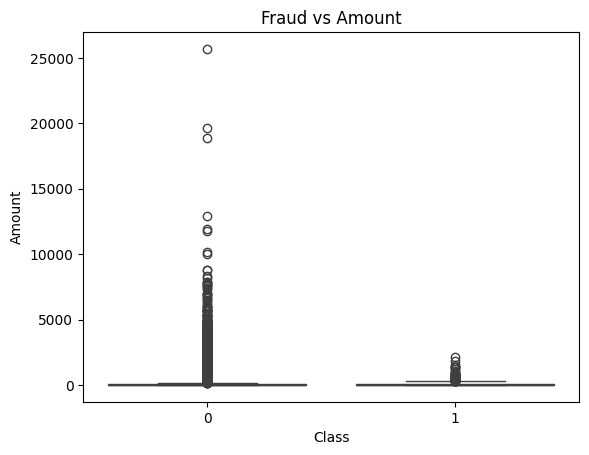

In [ ]:
sns.boxplot(x='Class', y='Amount', data=data)
plt.title("Fraud vs Amount")
plt.show()

##### ***the plot shows the fraud transactions(1) generally occur at lower amounts, while higher-value outliers are mostly normal(0).***

## **Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
X = data.drop('Class',axis=1)
y = data['Class']

In [ ]:
sc = StandardScaler()
x_scaled =sc.fit_transform(X)

In [ ]:
x_scaled = pd.DataFrame(sc.transform(X), columns=X.columns)
x_scaled

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-0.701082,-0.041687,1.680101,0.976623,-0.247020,0.348012,0.193700,0.084434,0.333534,0.085688,...,0.326273,-0.024777,0.383483,-0.177444,0.110157,0.247059,-0.392622,0.333033,-0.065850,0.244200
1,0.608792,0.164138,0.109279,0.318998,0.042258,-0.060980,-0.065656,0.072903,-0.231703,-0.153784,...,-0.089963,-0.311372,-0.881454,0.162081,-0.561503,0.321175,0.260854,-0.027154,0.043219,-0.342584
2,-0.700336,-0.811337,1.174270,0.270648,-0.366756,1.352655,0.643223,0.210788,-1.381169,0.194242,...,0.681564,0.343094,1.065068,1.457772,-1.138484,-0.628161,-0.288861,-0.144325,-0.183824,1.158900
3,-0.499064,-0.109972,1.187383,-0.608355,-0.008814,0.937245,0.192079,0.320843,-1.264664,-0.049713,...,-0.270428,-0.149093,0.007299,-0.305465,-1.941446,1.242487,-0.460694,0.154039,0.185687,0.139886
4,-0.597606,0.535539,1.025470,0.287092,-0.297036,0.072873,0.481517,-0.228725,0.747917,0.700958,...,0.530343,-0.012516,1.101780,-0.220709,0.232904,-0.394800,1.041677,0.550001,0.654234,-0.073813
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283721,-6.102103,6.118855,-6.519873,-1.459282,-3.897079,-1.956335,-4.007632,6.196662,1.749010,4.048299,...,1.916461,0.295375,0.154412,1.626230,-0.841382,2.757072,0.518377,2.380049,2.509507,-0.350252
283722,-0.379208,-0.030938,1.347812,-0.520175,0.629193,0.795504,0.018351,0.250814,0.535282,-0.905314,...,0.077182,0.296413,1.275826,0.019665,-1.678330,-1.163409,-0.820253,0.168567,-0.164849,-0.254325
283723,0.982354,-0.180433,-2.155033,-0.392355,1.908988,2.276699,-0.243249,0.601561,0.396215,-0.449033,...,0.001570,0.321057,0.798074,-0.060444,1.056626,0.510299,-0.181557,0.006802,-0.082640,-0.082239
283724,-0.126465,0.324660,0.464577,0.489870,-0.275808,0.469130,-0.560399,0.576734,0.359367,-0.369456,...,0.165259,0.366919,1.104223,-0.262138,0.203081,-1.091530,1.133734,0.270523,0.317004,-0.313391


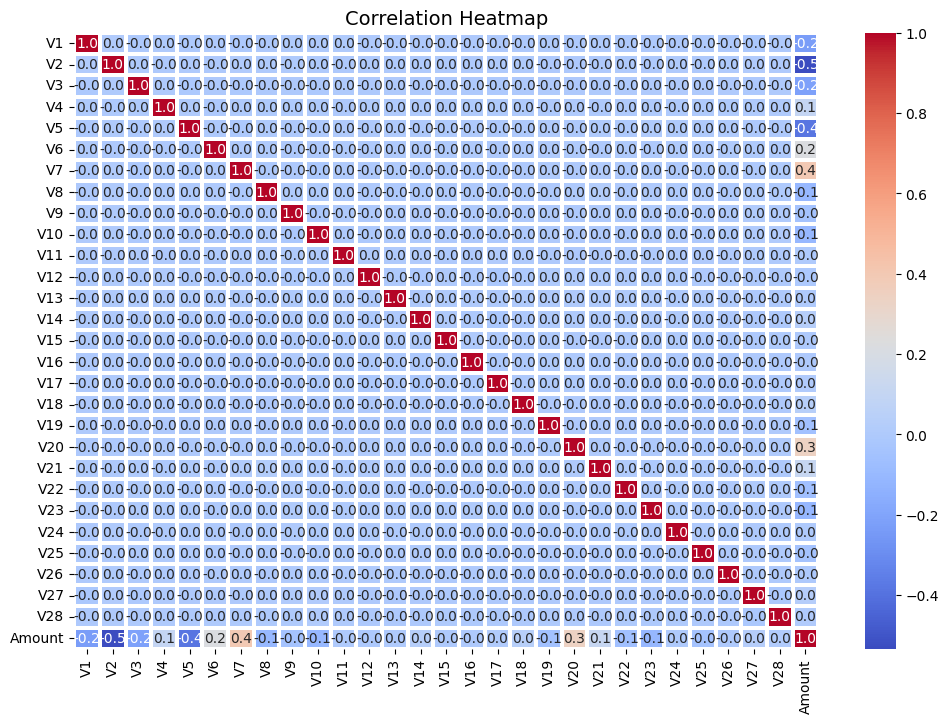

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(x_scaled.corr(), annot=True, cmap="coolwarm", fmt=".1f",linewidths=1.5)
plt.title("Correlation Heatmap", fontsize=14)
plt.show()

## **Train-Test-Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(x_scaled,y,test_size=0.20,random_state=42)

In [ ]:
X_train.shape

(226980, 29)

In [ ]:
X_test.shape

(56746, 29)

In [ ]:
y_train.shape

(226980,)

In [ ]:
y_test.shape

(56746,)

## **Sampling**

In [ ]:
data['Class'].value_counts()

,count
Class,
0,283253
1,473


In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
smote = SMOTE(random_state=42)
X_res,y_res = smote.fit_resample(X_train,y_train)

In [ ]:
print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:" ,np.bincount(y_res))

Before SMOTE: [226597    383]
After SMOTE: [226597 226597]


In [ ]:
y_res.value_counts()

,count
Class,
0,226597
1,226597


### **Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

In [ ]:
lr = LogisticRegression()
lr.fit(X_res,y_res)

LogisticRegression()

In [ ]:
y_pred_lr = lr.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred_lr)

0.9745356500898742

In [ ]:
precision_score(y_test,y_pred_lr)

0.052805280528052806

In [ ]:
recall_score(y_test,y_pred_lr)

0.8888888888888888

In [ ]:
f1_score(y_test,y_pred_lr)

0.09968847352024922

In [ ]:
y_prob_lr = lr.predict_proba(X_test)[:,1]

In [ ]:
roc_auc_score(y_test,y_prob_lr)

np.float64(0.9767817079293357)

### **Random Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(X_res, y_res)

In [ ]:
y_pred_rf = rf.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred_rf)

0.9983082508018186

In [ ]:
precision_score(y_test,y_pred_rf)

0.48

In [ ]:
recall_score(y_test,y_pred_rf)

0.8

In [ ]:
f1_score(y_test,y_pred_rf)

0.6

In [ ]:
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [ ]:
roc_auc_score(y_test,y_prob_rf)

np.float64(0.9759419420126142)

### **XGBoost Model**

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb = XGBClassifier(
    eval_metric='logloss',
    n_estimators=100,
    max_depth=6,
    n_jobs=-1
)

xgb.fit(X_res, y_res)

In [ ]:
y_pred_xgb = xgb.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred_xgb)

In [ ]:
precision_score(y_test,y_pred_xgb)

In [ ]:
recall_score(y_test,y_pred_xgb)

In [ ]:
f1_score(y_test,y_pred_xgb)

In [ ]:
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

In [ ]:
roc_auc_score(y_test,y_prob_xgb)

In [ ]:
rec_data = pd.DataFrame({'Models':['LR','RF','XGB'],
              "Recall":[recall_score(y_test,y_pred_lr)*100,
                     recall_score(y_test,y_pred_rf)*100,
                     recall_score(y_test,y_pred_xgb)*100
                    ]})

In [ ]:
rec_data

In [ ]:
sns.barplot(x='Models',y='Recall',data=rec_data)
plt.title("Model Recall Comparison")
plt.show()

In [ ]:
f1_data = pd.DataFrame({'Models':['LR','RF','XGB'],
              "ACC":[f1_score(y_test,y_pred_lr)*100,
                     f1_score(y_test,y_pred_rf)*100,
                     f1_score(y_test,y_pred_xgb)*100
                    ]})

In [ ]:
f1_data

In [ ]:
sns.barplot(x='Models',y='ACC',data=f1_data)
plt.title("Model Accuracy Comparison")
plt.show()

In [ ]:
roc_data = pd.DataFrame({'Models':['LR','RF','XGB'],
              "Roc_auc":[roc_auc_score(y_test,y_prob_lr)*100,
                     roc_auc_score(y_test,y_prob_rf)*100,
                     roc_auc_score(y_test,y_prob_xgb)*100
                    ]})

In [ ]:
roc_data

In [ ]:
sns.barplot(x='Models',y='Roc_auc',data=roc_data)
plt.title("Model Roc_auc Comparison")
plt.show()

In [ ]:
# Create empty list
data = []

# Logistic Regression
data.append([
    "Logistic",
    recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr),
    roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])
])

# Random Forest
data.append([
    "Random Forest",
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf),
    roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
])

# XGBoost
data.append([
    "XGBoost",
    recall_score(y_test, y_pred_xgb),
    f1_score(y_test, y_pred_xgb),
    roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])
])

# Convert to table
df = pd.DataFrame(data, columns=["Model", "Recall", "F1 Score", "ROC-AUC"])

# Show table
print(df)

##### ***XGBoost was selected as the final model due to its best balance between recall and F1-score.***

## **Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
xgb = XGBClassifier(eval_metric='logloss')

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='recall',
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}


In [ ]:
best_xgb = grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

## **Evaluate Performance**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

[[56653     3]
 [   28    62]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.95      0.69      0.80        90

    accuracy                           1.00     56746
   macro avg       0.98      0.84      0.90     56746
weighted avg       1.00      1.00      1.00     56746



##### ***The model achieved high precision and a good F1-score, indicating reliable fraud detection with minimal false positives.***

## **Save The Model**

In [ ]:
import joblib

# Save trained model
joblib.dump(best_xgb, "fraud_model.pkl")

# Save scaler
joblib.dump(sc, "scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [ ]:
model = joblib.load("fraud_model.pkl")
scaler = joblib.load("scaler.pkl")

print("Model loaded successfully!")

Model loaded successfully!


## **Predict the Model**

In [ ]:
X_test = pd.DataFrame(X_test)
sample = X_test.iloc[[0]]
pred1=model.predict(sample)

In [ ]:
if pred1[0] == 0:
    print("Normal Transcation")
else:
    print("Fraudulent Transcation")

Normal Transcation


In [ ]:
if pred1[0] == 541:
    print("Normal Transcation")
else:
    print("Fraudulent Transcation")

Fraudulent Transcation


In [ ]:
from google.colab import files
files.download("fraud_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>